In [1]:
import numpy as np
import urllib.request
import tensorflow as tf
import matplotlib.pyplot as plt

# ── Categorías elegidas para el proyecto ───────────────────────────
clases = ['gato', 'casa', 'sol', 'bicicleta', 'paraguas']

# El dataset de Google usa nombres en inglés para los archivos
nombres_archivo = {
    'gato': 'cat',
    'casa': 'house',
    'sol': 'sun',
    'bicicleta': 'bicycle',
    'paraguas': 'umbrella'
}

# ── Descargar cada categoría ────────────────────────────────────────
base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

for clase_es, clase_en in nombres_archivo.items():
    url = f"{base_url}{clase_en}.npy"
    archivo_local = f"{clase_en}.npy"
    print(f"Descargando {clase_es} ({clase_en})...")
    urllib.request.urlretrieve(url, archivo_local)

print("✅ Descarga completa")

Descargando gato (cat)...
Descargando casa (house)...
Descargando sol (sun)...
Descargando bicicleta (bicycle)...
Descargando paraguas (umbrella)...
✅ Descarga completa


In [2]:
IMAGENES_POR_CLASE = 2000  # cumple el mínimo pedido en la tarea

X = []
y = []

for idx, (clase_es, clase_en) in enumerate(nombres_archivo.items()):
    datos = np.load(f"{clase_en}.npy")

    # Cada archivo trae MUCHAS más de 2000 imágenes (decenas de miles) —
    # tomamos solo las primeras 2000 para mantener el dataset balanceado
    # y manejable en tiempo de entrenamiento
    datos = datos[:IMAGENES_POR_CLASE]

    # Vienen como vector plano de 784 valores — los regresamos a 28x28
    datos = datos.reshape(-1, 28, 28)

    X.append(datos)
    y.append(np.full(len(datos), idx))  # etiqueta = índice de la clase

    print(f"{clase_es}: {len(datos)} imágenes cargadas")

X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

print(f"\nTotal de imágenes: {X.shape}")
print(f"Total de etiquetas: {y.shape}")

gato: 2000 imágenes cargadas
casa: 2000 imágenes cargadas
sol: 2000 imágenes cargadas
bicicleta: 2000 imágenes cargadas
paraguas: 2000 imágenes cargadas

Total de imágenes: (10000, 28, 28)
Total de etiquetas: (10000,)


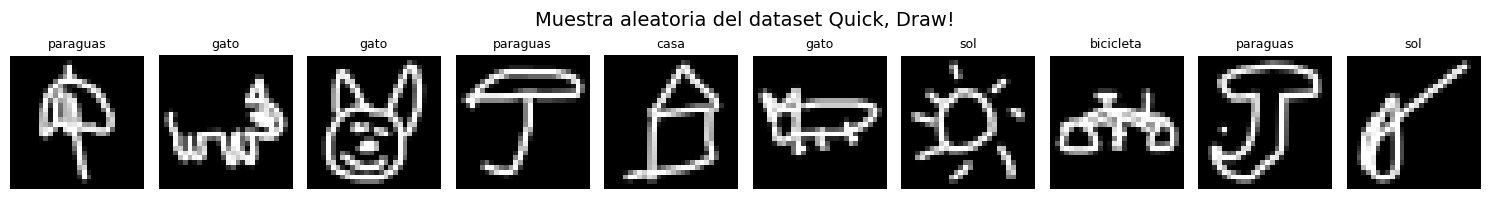

In [3]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
indices_muestra = np.random.randint(0, len(X), size=10)

for i, idx in enumerate(indices_muestra):
    axes[i].imshow(X[idx], cmap="gray")
    axes[i].set_title(clases[y[idx]], fontsize=9)
    axes[i].axis('off')

plt.suptitle("Muestra aleatoria del dataset Quick, Draw!", fontsize=14)
plt.tight_layout()
plt.show()

Mezclar aleatoriamente

 Importante: como concatenamos clase por clase, ahora mismo X e y
 están ordenados (todos los gatos, luego todas las casas, etc.).
 Si no mezclamos antes de dividir, el set de test podría quedar
 con clases incompletas.

In [4]:

np.random.seed(42)
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

# ── Dividir en entrenamiento (80%) y prueba (20%) ──────────────────
corte = int(len(X) * 0.8)
X_train, X_test = X[:corte], X[corte:]
y_train, y_test = y[:corte], y[corte:]

# ── Normalizar (misma razón que en Fashion-MNIST: 0-255 → 0-1) ─────
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")
print(f"Valor mínimo: {X_train.min()}, valor máximo: {X_train.max()}")

# Verificar que las clases quedaron balanceadas en ambos conjuntos
print("\nDistribución en entrenamiento:", np.bincount(y_train))
print("Distribución en prueba:", np.bincount(y_test))

Entrenamiento: (8000, 28, 28)
Prueba: (2000, 28, 28)
Valor mínimo: 0.0, valor máximo: 1.0

Distribución en entrenamiento: [1600 1617 1603 1581 1599]
Distribución en prueba: [400 383 397 419 401]


 Agregar dimensión de canal

 Conv2D espera (alto, ancho, canales), aunque sea escala de grises
 (1 solo canal).

 Ahora mismo X_train tiene forma (8000, 28, 28)
 le agregamos el canal para que quede (8000, 28, 28, 1)


In [5]:
# ── Agregar dimensión de canal ──────────────────────────────────────
# Conv2D espera (alto, ancho, canales), aunque sea escala de grises
# (1 solo canal). Ahora mismo X_train tiene forma (8000, 28, 28) —
# le agregamos el canal para que quede (8000, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Nueva forma de X_train:", X_train.shape)
print("Nueva forma de X_test:", X_test.shape)

Nueva forma de X_train: (8000, 28, 28, 1)
Nueva forma de X_test: (2000, 28, 28, 1)


In [6]:
modelo = tf.keras.models.Sequential([

    # Primera capa convolucional: 32 filtros buscan patrones básicos
    # (bordes, curvas) en la imagen del trazo
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional: 64 filtros combinan los patrones
    # básicos de la capa anterior en patrones más complejos (formas)
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Aplanar antes de las capas Dense finales
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),

    # Dropout: apaga el 30% de las neuronas al azar durante el
    # entrenamiento para evitar que el modelo memorice los trazos
    # en vez de aprender el patrón general de cada categoría
    tf.keras.layers.Dropout(0.3),

    # Capa de salida: 5 neuronas (una por categoría), softmax porque
    # es clasificación de más de 2 clases
    tf.keras.layers.Dense(5, activation='softmax')
])

modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,389 (876.52 KB)

 Trainable params: 224,389 (876.52 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia = modelo.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8487 - loss: 0.4470 - val_accuracy: 0.9325 - val_loss: 0.2554
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9442 - loss: 0.1773 - val_accuracy: 0.9413 - val_loss: 0.2243
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9607 - loss: 0.1220 - val_accuracy: 0.9388 - val_loss: 0.2152
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9699 - loss: 0.0962 - val_accuracy: 0.9450 - val_loss: 0.1776
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9762 - loss: 0.0727 - val_accuracy: 0.9500 - val_loss: 0.1809
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9826 - loss: 0.0549 - val_accuracy: 0.9438 - val_loss: 0.2052
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9853 - loss: 0.0448 - val_accuracy: 0.9513 - val_loss: 0.1920
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9904 - loss: 0.0302 - val_accu

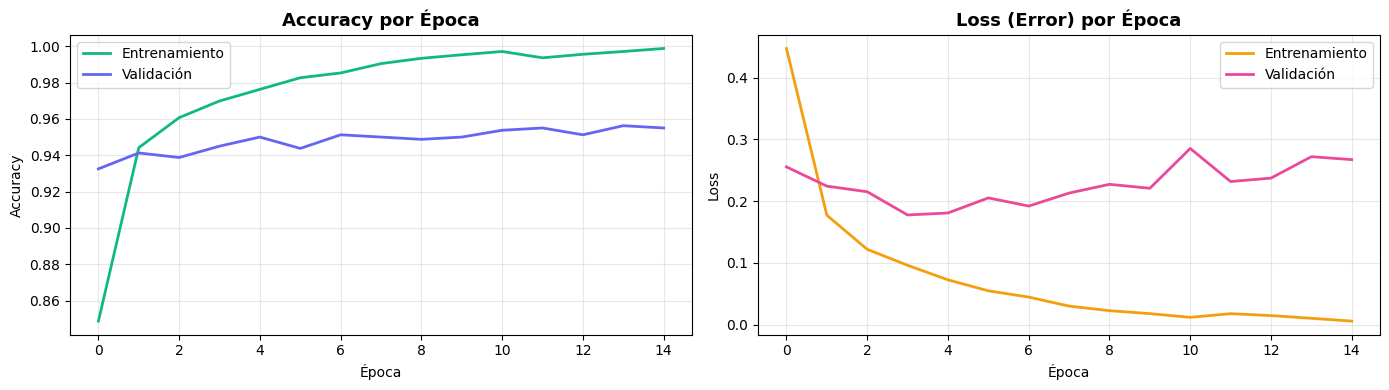

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(historia.history['accuracy'], label='Entrenamiento', color='#10B981', linewidth=2)
ax1.plot(historia.history['val_accuracy'], label='Validación', color='#6366F1', linewidth=2)
ax1.set_title('Accuracy por Época', fontsize=13, fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(historia.history['loss'], label='Entrenamiento', color='#F59E0B', linewidth=2)
ax2.plot(historia.history['val_loss'], label='Validación', color='#EC4899', linewidth=2)
ax2.set_title('Loss (Error) por Época', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
loss_final, accuracy_final = modelo.evaluate(X_test, y_test, verbose=0)

print(f"Resultados en datos de prueba:")
print(f"   Loss (error):  {loss_final:.4f}")
print(f"   Accuracy:      {accuracy_final*100:.2f}%")

if accuracy_final >= 0.75:
    print("   ✅ Cumple la meta mínima de accuracy del proyecto (75%)")
else:
    print("   ⚠️ Aún no llega al 75% mínimo — considera más épocas o ajustar la arquitectura")

Resultados en datos de prueba:
   Loss (error):  0.1549
   Accuracy:      96.90%
   ✅ Cumple la meta mínima de accuracy del proyecto (75%)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


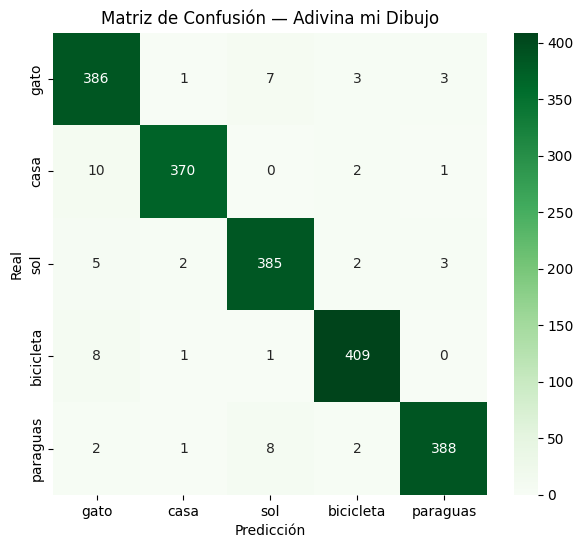

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predicciones = modelo.predict(X_test).argmax(axis=1)
matriz = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(7, 6))
sns.heatmap(matriz, annot=True, fmt='d', xticklabels=clases, yticklabels=clases, cmap='Greens')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión — Adivina mi Dibujo')
plt.show()

# ── Guardar el modelo en formato .h5 ────────────────────────────────
# Esto guarda la arquitectura, los pesos entrenados y la configuración
# de compilación, todo en un solo archivo — es el entregable que pide
# la tarea ("modelo entrenado exportado")

In [11]:
# ── Guardar el modelo en formato .h5 ────────────────────────────────
# Esto guarda la arquitectura, los pesos entrenados y la configuración
# de compilación, todo en un solo archivo — es el entregable que pide
# la tarea ("modelo entrenado exportado")
modelo.save('adivina_mi_dibujo.h5')

print("✅ Modelo guardado como adivina_mi_dibujo.h5")

# Si trabajas en Colab, descárgalo a tu computadora para subirlo
# después a tu repositorio de GitHub:
from google.colab import files
files.download('adivina_mi_dibujo.h5')

✅ Modelo guardado como adivina_mi_dibujo.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
!pip install gradio -q

In [13]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# ── Cargar el modelo ya entrenado ───────────────────────────────────
# (si vienes corriendo todo en la misma sesión de Colab, modelo ya
# existe en memoria y este paso es opcional — pero así queda el
# notebook listo para correr de forma independiente)
modelo = tf.keras.models.load_model('adivina_mi_dibujo.h5')

clases = ['gato', 'casa', 'sol', 'bicicleta', 'paraguas']


def predecir(dibujo):
    # ── El Sketchpad de Gradio entrega un diccionario con la imagen
    # dibujada en la clave "composite" (capa final combinada) ───────
    if dibujo is None or dibujo["composite"] is None:
        return {c: 0.0 for c in clases}

    imagen = dibujo["composite"]

    # Convertir a escala de grises y redimensionar a 28x28,
    # EXACTAMENTE el mismo formato que usamos al entrenar
    imagen = Image.fromarray(imagen).convert("L").resize((28, 28))
    imagen_array = np.array(imagen)

    # El Sketchpad dibuja trazos oscuros sobre fondo claro;
    # Quick Draw es al revés (trazo claro sobre fondo negro) —
    # invertimos los colores para que coincida con lo que aprendió el modelo
    imagen_array = 255 - imagen_array

    # Misma normalización que en entrenamiento
    imagen_array = imagen_array / 255.0
    imagen_array = imagen_array.reshape(1, 28, 28, 1)

    # Predecir
    probabilidades = modelo.predict(imagen_array, verbose=0)[0]

    # Gradio espera un diccionario {categoria: probabilidad}
    resultado = {clases[i]: float(probabilidades[i]) for i in range(len(clases))}
    return resultado


# ── Armar la interfaz ───────────────────────────────────────────────
interfaz = gr.Interface(
    fn=predecir,
    inputs=gr.Sketchpad(
        image_mode="RGB",
        brush=gr.Brush(default_size=8, colors=["#000000"], color_mode="fixed")
    ),
    outputs=gr.Label(num_top_classes=3, label="Predicciones"),
    live=True,  # se actualiza mientras dibujas, sin botón "enviar"
    title="🎨 Adivina mi Dibujo",
    description=f"Dibuja uno de estos objetos: {', '.join(clases)}"
)

interfaz.launch(share=True)  # share=True genera el link público para grabar el video

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://709f714ff1f896461c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
